In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.models.model_loader import load_model
from src.models.model_loader import load_vectorizer

model = load_model()

vectorizer = load_vectorizer()

print(type(model))
print(type(vectorizer))

<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [3]:
feature_names = vectorizer.get_feature_names_out()

print("Total Features:", len(feature_names))

print(feature_names[:20])

Total Features: 10000
['00' '00 00' '00 hour' '00 pm' '000' '000 people' '000 year' '00am'
 '01a736d89d2f0b19de700923d2c312837ed0fbf9a' '0cm'
 '0fa3f7c5e23a16de16a841e368006caed90b154dfef3976483a71ae'
 '0fa3f7c5e23a16de16a841e368006caed90b154dfef3976483a71ae information'
 '0in' '0in 4pt' '0in mso' '0pt' '0pt font' '10' '10 00' '10 000']


In [4]:
importance = model.feature_importances_

print("Total Importances:", len(importance))

Total Importances: 10000


In [5]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
1275,candidates encouraged,0.113078
10,0fa3f7c5e23a16de16a841e368006caed90b154dfef397...,0.084163
2264,data entry,0.038452
3375,experience required,0.025876
382,administrative assistant,0.017419
9808,work home,0.015638
4434,income,0.014787
381,administrative,0.012854
2979,encouraged,0.012335
8542,streamline hiring,0.012307


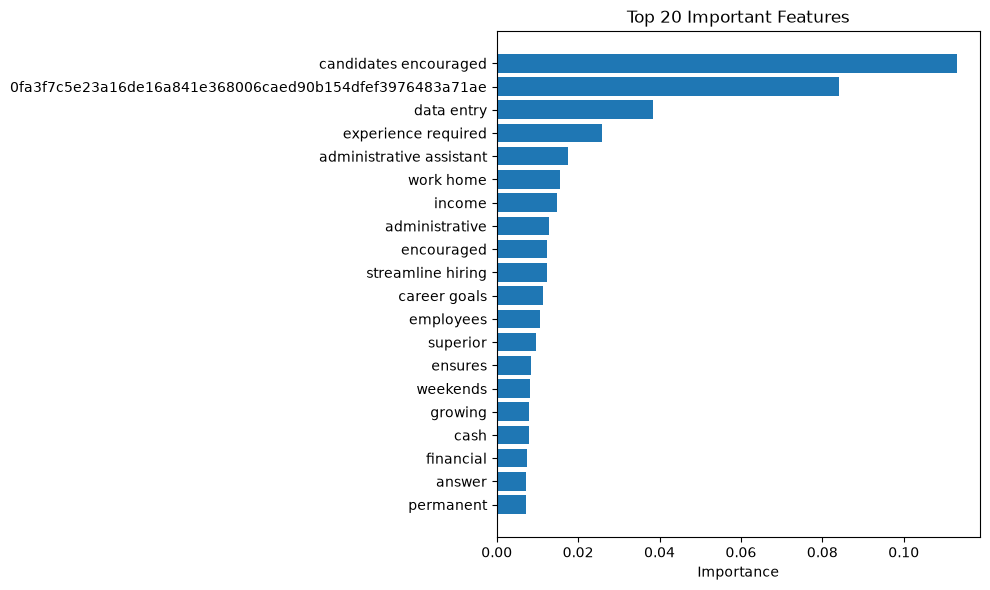

In [6]:
top20 = importance_df.head(20)

plt.figure(figsize=(10, 6))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [7]:
importance_df.to_csv(
    "../artifacts/feature_importance.csv",
    index=False
)

print("✅ Feature Importance Saved")

✅ Feature Importance Saved


In [11]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_jobs.csv")

print(df.shape)

(17880, 17)


In [12]:
from src.models.model_loader import load_model, load_vectorizer

model = load_model()
vectorizer = load_vectorizer()

In [13]:
X = vectorizer.transform(df["combined_text"])

y = df["fraudulent"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3400    3]
 [  63  110]]


In [17]:
import numpy as np

fp_idx = np.where((y_test == 0) & (y_pred == 1))[0]

fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]

print("False Positives :", len(fp_idx))
print("False Negatives :", len(fn_idx))

False Positives : 3
False Negatives : 63


In [18]:
test_df = df.loc[y_test.index].copy()

test_df["prediction"] = y_pred

false_negative_jobs = test_df[
    (test_df["fraudulent"] == 1) &
    (test_df["prediction"] == 0)
]

false_negative_jobs[
    ["title", "combined_text", "fraudulent", "prediction"]
].head(10)

,title,combined_text,fraudulent,prediction
7830,position finance assistant,position finance assistant we have positions ...,1,0
8836,maintenance specialist,maintenance specialist as the industry s large...,1,0
17648,vemma brand partner,vemma brand partner looking for motivated and...,1,0
17604,subsea installation engineer,subsea installation engineer job description ...,1,0
12104,production manager heavy duty diesel 2022,production manager heavy duty diesel 2022 202...,1,0
17655,controls engineer troy mi,controls engineer troy mi systems technology i...,1,0
17549,sales manager,sales manager collaborates with insert title ...,1,0
7177,fraud detection analyst,fraud detection analyst as the industry s larg...,1,0
17652,clerical assistant,clerical assistant the clerical assistant wil...,1,0
17619,job vacancy in st ermin s hotel london,job vacancy in st ermin s hotel london st erm...,1,0
